#  TrialScout — Agentic Clinical-Trial Matching
### Hybrid retrieval · contrastively fine-tuned embeddings · cross-encoder reranking · LangGraph agent · FastMCP + FastAPI + Gradio

**Problem.** Finding a clinical trial you can actually join is painful: ~thousands of *recruiting* studies, free-text
eligibility rules, and patients who describe their illness in everyday language ("shaking hands and stiff, slow walking"),
not registry vocabulary ("Parkinson Disease").

**What this notebook builds (end to end, on a free Colab T4):**

| Layer | What | Why it matters |
|---|---|---|
| Data | Live pull of recruiting trials from the public **ClinicalTrials.gov v2 API** (20 conditions) | Real, messy, production-shaped data |
| Retrieval | **BM25 ⊕ dense (BGE) → Reciprocal Rank Fusion → cross-encoder rerank** | Modern hybrid search stack, ablated stage by stage |
| Representation learning | **From-scratch InfoNCE fine-tuning** with *false-negative masking*, evaluated on **held-out trials *and* held-out patient phrasings** | Rigorous ML, not just API calls |
| Constraints | Age/sex hard filters + exclusion-criteria screening | Retrieval alone ignores eligibility; this is the real product problem |
| Agent | **LangGraph** state machine: intake (PII scrub) → route → retrieve → verify → grounded explain → report | Agentic control flow with guardrails |
| Serving | **FastMCP** tools, **FastAPI** endpoint, **Gradio** demo | Same core exposed to agents, services, and humans |

**Architecture**
```
free text ─► [intake: PII scrub + parse age/sex] ──missing demographics?──► [clarify] ─► END
                 │
                 ▼
   [retrieve: BM25 ⊕ FT-BGE dense ─► RRF ─► age/sex constraints ─► cross-encoder rerank]
                 │ no hits ─► [no_match] ─► END
                 ▼
   [verify: exclusion-criteria screening]  ─►  [explain: grounded local LLM]  ─►  [report]
                                                                                    │
                    exposed as:  FastMCP tools  ·  FastAPI /match  ·  Gradio UI  ◄──┘
```

**How to run:** `Runtime → Change runtime type → T4 GPU`, then `Run all` (~10–15 min). No API keys needed.

> ⚠️ **Research demo, not medical advice.** Matching is decision *support* for a coordinator/clinician, never a substitute for one.

In [1]:
!pip install -q sentence-transformers rank_bm25 faiss-cpu langgraph fastmcp fastapi httpx gradio accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.4/875.4 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.4/169.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.7/365.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.3/171.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 12.4 MB/s eta 0:00:00


In [2]:
import os, re, json, math, time, random, asyncio, warnings
from collections import defaultdict
from typing import TypedDict
import numpy as np, pandas as pd, requests, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE == "cuda" else "(tip: Runtime → T4 GPU for faster training)")

# Everything tunable lives here.
CONFIG = dict(
    per_condition=120,                       # recruiting trials pulled per condition
    bi_encoder="BAAI/bge-small-en-v1.5",
    reranker="cross-encoder/ms-marco-MiniLM-L-6-v2",
    llm="Qwen/Qwen2.5-1.5B-Instruct",        # local, grounded explainer (optional)
    use_llm=True,
    max_seq_len=256,
    n_train_patients=2000, n_eval_patients=300,
    epochs=3, batch_size=32, lr=3e-5, scale=20.0,
    cache_path="/content/trials_cache.json",
    force_synthetic=False,                   # True → skip the API and use the built-in synthetic corpus
)

# clinical name, a lay phrasing used for TRAINING, and a different lay phrasing held out for EVALUATION.
LAY = {
 "type 2 diabetes":            ["type 2 diabetes", "adult-onset diabetes and trouble controlling blood sugar", "high blood glucose despite taking pills"],
 "breast cancer":              ["breast cancer", "cancer in the breast", "a malignant lump in my breast that was found on a mammogram"],
 "lung cancer":                ["lung cancer", "cancer in the lungs", "a tumor in my lung, biopsy confirmed"],
 "heart failure":              ["heart failure", "a weak heart that struggles to pump", "breathlessness and swollen ankles from a failing heart"],
 "asthma":                     ["asthma", "wheezing and airway tightness", "recurrent breathing attacks triggered by exercise and dust"],
 "COPD":                       ["COPD", "chronic lung disease from smoking", "long-term breathlessness and emphysema"],
 "psoriasis":                  ["plaque psoriasis", "scaly red skin patches", "itchy silvery plaques on elbows and scalp"],
 "rheumatoid arthritis":       ["rheumatoid arthritis", "painful swollen joints from autoimmune arthritis", "morning stiffness and inflamed hand joints"],
 "major depressive disorder":  ["major depressive disorder", "clinical depression", "persistent low mood and loss of interest"],
 "alzheimer disease":          ["Alzheimer's disease", "progressive memory loss and dementia", "worsening forgetfulness and confusion"],
 "parkinson disease":          ["Parkinson's disease", "tremor and slow movement", "shaking hands and stiff, slow walking"],
 "multiple sclerosis":         ["multiple sclerosis", "MS, an autoimmune nerve disease", "relapsing numbness, vision problems and fatigue from demyelination"],
 "hypertension":               ["hypertension", "high blood pressure", "blood pressure readings that stay elevated"],
 "chronic kidney disease":     ["chronic kidney disease", "declining kidney function", "reduced kidney filtering with protein in urine"],
 "migraine":                   ["migraine", "severe recurring headaches", "throbbing headaches with nausea and light sensitivity"],
 "atrial fibrillation":        ["atrial fibrillation", "irregular heartbeat", "palpitations from an erratic heart rhythm"],
 "ulcerative colitis":         ["ulcerative colitis", "inflammatory bowel disease of the colon", "bloody diarrhea and cramping from colon inflammation"],
 "melanoma":                   ["melanoma", "aggressive skin cancer", "a malignant mole that has spread"],
 "prostate cancer":            ["prostate cancer", "cancer of the prostate", "rising PSA and a prostate tumor"],
 "osteoarthritis":             ["osteoarthritis", "worn-out joint cartilage", "knee pain and stiffness from wear and tear"],
}
CONDITIONS = list(LAY)
print(len(CONDITIONS), "conditions configured")

Device: cuda Tesla T4
20 conditions configured


## 1 · Data: live ClinicalTrials.gov ingestion
Public v2 REST API, no key. Falls back to a built-in synthetic corpus if the API is unreachable, so the notebook always runs.

In [3]:
API = "https://clinicaltrials.gov/api/v2/studies"

def ct_age_to_years(s):
    """'18 Years' → 18.0, '6 Months' → 0.5, None → None"""
    if not s: return None
    m = re.match(r"\s*(\d+)\s*(Year|Month|Week|Day)", s, re.I)
    if not m: return None
    v, u = int(m.group(1)), m.group(2).lower()
    return float(v) if u == "year" else v/12 if u == "month" else v/52 if u == "week" else v/365

def parse_study(s):
    p = s.get("protocolSection", {})
    idm, st, de = p.get("identificationModule", {}), p.get("statusModule", {}), p.get("descriptionModule", {})
    co, el, ds = p.get("conditionsModule", {}), p.get("eligibilityModule", {}), p.get("designModule", {})
    ai, cl = p.get("armsInterventionsModule", {}), p.get("contactsLocationsModule", {})
    return dict(
        nct_id=idm.get("nctId"), title=idm.get("briefTitle", ""), status=st.get("overallStatus"),
        summary=de.get("briefSummary", "") or "", conditions=co.get("conditions", []),
        interventions=[i.get("name", "") for i in ai.get("interventions", [])],
        phases=ds.get("phases", []), sex=(el.get("sex") or "ALL").upper(),
        min_age=ct_age_to_years(el.get("minimumAge")), max_age=ct_age_to_years(el.get("maximumAge")),
        criteria=el.get("eligibilityCriteria", "") or "",
        countries=sorted({l.get("country") for l in cl.get("locations", []) if l.get("country")}),
    )

def fetch_condition(cond, n, status="RECRUITING"):
    studies, token = [], None
    while len(studies) < n:
        params = {"query.cond": cond, "filter.overallStatus": status, "pageSize": min(100, n - len(studies)), "format": "json"}
        if token: params["pageToken"] = token
        for attempt in range(3):
            try:
                r = requests.get(API, params=params, timeout=40); r.raise_for_status(); break
            except Exception:
                if attempt == 2: raise
                time.sleep(2 * (attempt + 1))
        js = r.json(); studies += js.get("studies", []); token = js.get("nextPageToken")
        if not token: break
    return studies[:n]

def synthetic_corpus(per_condition=60, seed=SEED):
    """Offline fallback: template-generated trials with realistic age/sex constraints."""
    rng = random.Random(seed)
    drugs = ["Zelrumab", "Corvantin", "Nexaprol", "Lumitinib", "Veradex", "Orvelimab", "Talvestat", "Pyrexon"]
    excl = ["Pregnant or breastfeeding", "Current smoker", "Severe renal impairment", "Active liver disease or hepatitis",
            "Uncontrolled anemia", "Prior organ transplant", "History of stroke within 6 months", "Known HIV infection"]
    trials = []
    for cond in CONDITIONS:
        for _ in range(per_condition):
            sex = "MALE" if cond == "prostate cancer" else (rng.choice(["FEMALE"] * 4 + ["ALL"]) if cond == "breast cancer" else "ALL")
            lo = rng.choice([18, 18, 18, 40, 50, 65]); hi = rng.choice([None, None, 75, 80, 85])
            drug, phase = rng.choice(drugs), rng.choice(["PHASE1", "PHASE2", "PHASE3"])
            trials.append(dict(
                nct_id=f"SYN{len(trials):05d}", title=f"A {phase.replace('PHASE', 'Phase ')} Study of {drug} in Adults With {cond.title()}",
                status="RECRUITING",
                summary=f"This randomized study evaluates the safety and efficacy of {drug} compared with standard care in participants diagnosed with {cond}. "
                        f"Participants are followed for 24 weeks.",
                conditions=[cond], interventions=[drug], phases=[phase], sex=sex, min_age=float(lo), max_age=float(hi) if hi else None,
                criteria="Inclusion Criteria:\n\n* Confirmed diagnosis of " + cond + f"\n* Age >= {lo} years\n\nExclusion Criteria:\n\n* "
                         + "\n* ".join(rng.sample(excl, 3)),
                countries=["United States"], seeds=[cond]))
    return trials

def build_corpus():
    if CONFIG["force_synthetic"]:
        return synthetic_corpus(), "synthetic"
    if os.path.exists(CONFIG["cache_path"]):
        return json.load(open(CONFIG["cache_path"])), "ClinicalTrials.gov (cached)"
    try:
        by_id = {}
        for cond in CONDITIONS:
            for s in fetch_condition(cond, CONFIG["per_condition"]):
                t = parse_study(s)
                if not t["nct_id"] or len(t["summary"]) < 50 or not t["criteria"]: continue
                if t["nct_id"] in by_id:
                    if cond not in by_id[t["nct_id"]]["seeds"]: by_id[t["nct_id"]]["seeds"].append(cond)
                else:
                    t["seeds"] = [cond]; by_id[t["nct_id"]] = t
            print(f"  {cond:28s} → {len(by_id)} unique trials so far")
        trials = list(by_id.values())
        json.dump(trials, open(CONFIG["cache_path"], "w"))
        return trials, "ClinicalTrials.gov"
    except Exception as e:
        print("⚠️ API unavailable, using synthetic corpus:", repr(e)[:150])
        return synthetic_corpus(), "synthetic"

TRIALS, SOURCE = build_corpus()
TRIAL_BY_ID = {t["nct_id"]: t for t in TRIALS}
print(f"\nCorpus: {len(TRIALS)} trials · source = {SOURCE}")

  type 2 diabetes              → 120 unique trials so far
  breast cancer                → 240 unique trials so far
  lung cancer                  → 346 unique trials so far
  heart failure                → 466 unique trials so far
  asthma                       → 584 unique trials so far
  COPD                         → 686 unique trials so far
  psoriasis                    → 805 unique trials so far
  rheumatoid arthritis         → 915 unique trials so far
  major depressive disorder    → 1035 unique trials so far
  alzheimer disease            → 1152 unique trials so far
  parkinson disease            → 1265 unique trials so far
  multiple sclerosis           → 1376 unique trials so far
  hypertension                 → 1482 unique trials so far
  chronic kidney disease       → 1591 unique trials so far
  migraine                     → 1711 unique trials so far
  atrial fibrillation          → 1824 unique trials so far
  ulcerative colitis           → 1938 unique trials so far
  mel

age-limited: 96% have a minimum age · 9% are sex-restricted · 5% match several seed conditions


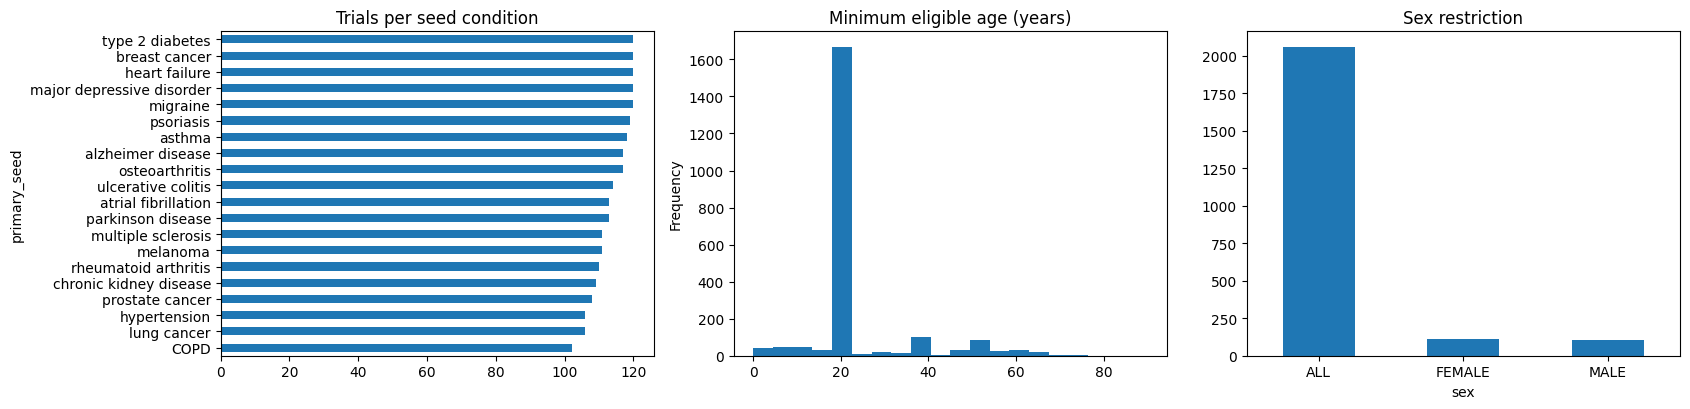

In [4]:
df = pd.DataFrame(TRIALS)
df["primary_seed"] = df["seeds"].str[0]
print(f"age-limited: {df.min_age.notna().mean():.0%} have a minimum age · {(df.sex != 'ALL').mean():.0%} are sex-restricted · "
      f"{(df.seeds.str.len() > 1).mean():.0%} match several seed conditions")
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
df["primary_seed"].value_counts().sort_values().plot.barh(ax=ax[0], title="Trials per seed condition")
df["min_age"].dropna().clip(upper=90).plot.hist(bins=20, ax=ax[1], title="Minimum eligible age (years)")
df["sex"].value_counts().plot.bar(ax=ax[2], title="Sex restriction", rot=0)
plt.tight_layout(); plt.show()

## 2 · Domain logic: eligibility, criteria parsing, document representation
Two ideas worth noting: (1) age/sex are **hard constraints** that embeddings cannot reliably encode, so they are enforced
symbolically; (2) eligibility text is split into inclusion/exclusion bullets so exclusions can be screened explicitly.

In [5]:
def age_ok(age, t):
    lo = t["min_age"] if t.get("min_age") is not None else 0
    hi = t["max_age"] if t.get("max_age") is not None else 200
    return lo <= age <= hi

def sex_ok(sex, t):
    return (t.get("sex") or "ALL") == "ALL" or (t["sex"] or "").upper() == (sex or "").upper()

def split_criteria(text):
    """Return (inclusion_bullets, exclusion_bullets) from CT.gov free-text eligibility criteria."""
    text = text or ""
    m = re.search(r"exclusion criteria", text, re.I)
    inc, exc = (text[:m.start()], text[m.end():]) if m else (text, "")
    def bullets(t):
        t = re.sub(r"inclusion criteria:?", "", t, flags=re.I)
        parts = re.split(r"\n\s*(?:[-*•]|\d+[.)])\s+|\n{2,}", t)
        return [re.sub(r"\s+", " ", x).strip(" :-*•") for x in parts if len(x.strip(" :-*•")) > 8]
    return bullets(inc), bullets(exc)

def doc_text(t, max_chars=1400):
    inc, _ = split_criteria(t["criteria"])
    parts = [t["title"], "Conditions: " + ", ".join(t["conditions"][:6]), "Interventions: " + ", ".join(t["interventions"][:5]),
             "Summary: " + re.sub(r"\s+", " ", t["summary"])[:600], "Key inclusion: " + " | ".join(inc[:4])]
    return ". ".join(p for p in parts if p.strip())[:max_chars]

print(doc_text(TRIALS[0])[:500], "\n")
inc, exc = split_criteria(TRIALS[0]["criteria"]); print("inclusion bullets:", len(inc), "· exclusion bullets:", len(exc))

PREvention of CardIovascular and DiabEtic kidNey Disease in Type 2 Diabetes. Conditions: Type2Diabetes, ASCVD. Interventions: SGLT2 inhibitor, GLP-1 receptor agonist. Summary: PRECIDENTD is a randomized, open label, pragmatic clinical trial designed to compare rates of the total number of cardiovascular, kidney, and death events among two alternative treatments for patients with type 2 diabetes (T2D) and either established atherosclerotic cardiovascular disease (ASCVD) or at high risk for ASCVD. 

inclusion bullets: 18 · exclusion bullets: 20


## 3 · Benchmark design (no leakage, no hand-waving)
There is no public labelled "patient → trial" set that fits this task, so I build a **rule-grounded benchmark** and am explicit about its limits:

* **Synthetic patients** with condition, age, sex, comorbidities, and templated free-text (3 templates).
* **Graded relevance** per (patient, trial): `2` = right condition **and** age/sex-eligible · `1` = right condition but ineligible · `0` = otherwise.
* **Two held-out axes** so fine-tuning cannot just memorise: trials are split 80/20 by trial (evaluation runs against the *unseen* 20%), and
  evaluation patients use a **lay phrasing never seen in training**.
* Metrics: **nDCG@10** (graded), **MRR** (first fully eligible hit), **Eligible-P@10** (share of top-10 that are right-condition *and* eligible), latency.

Limitation (also in the model card): relevance comes from registry condition tags + age/sex rules, not from clinician adjudication.

In [6]:
AGE_MEAN = defaultdict(lambda: 55, {"psoriasis": 45, "migraine": 38, "multiple sclerosis": 40, "asthma": 40, "alzheimer disease": 74,
    "parkinson disease": 68, "prostate cancer": 68, "COPD": 66, "atrial fibrillation": 70, "heart failure": 68, "melanoma": 60,
    "major depressive disorder": 42, "ulcerative colitis": 38, "osteoarthritis": 63, "type 2 diabetes": 58})
FEMALE_PRIOR = defaultdict(lambda: 0.5, {"breast cancer": 0.99, "prostate cancer": 0.0, "migraine": 0.75, "rheumatoid arthritis": 0.7,
    "multiple sclerosis": 0.72, "major depressive disorder": 0.62, "alzheimer disease": 0.62})
COMORB = ["seasonal allergies", "mild anemia", "a past appendectomy", "former smoker", "vitamin D deficiency",
          "occasional insomnia", "lower back pain", "obesity"]
TEMPLATES = [
    "{age}-year-old {who} with {phrase}. Also has {como}. Looking for a clinical trial.",
    "I am a {age} year old {who} living with {phrase}; other health notes: {como}. What research studies could I join?",
    "Patient: {who}, {age}. Reports {phrase}. History includes {como}.",
]

def make_patients(n, variants, seed):
    rng = random.Random(seed); out = []
    for i in range(n):
        cond = CONDITIONS[i % len(CONDITIONS)]
        sex = "FEMALE" if rng.random() < FEMALE_PRIOR[cond] else "MALE"
        age = int(np.clip(rng.gauss(AGE_MEAN[cond], 12), 18, 90))
        como = rng.sample(COMORB, rng.choice([1, 2]))
        text = rng.choice(TEMPLATES).format(age=age, who="woman" if sex == "FEMALE" else "man",
                                            phrase=LAY[cond][rng.choice(variants)], como=" and ".join(como))
        out.append(dict(condition=cond, age=age, sex=sex, comorbidities=como, text=text))
    return out

def relevance_vector(p, trials):
    rel = np.zeros(len(trials), dtype=int)
    for j, t in enumerate(trials):
        if p["condition"] in t["seeds"]:
            rel[j] = 2 if (age_ok(p["age"], t) and sex_ok(p["sex"], t)) else 1
    return rel

# trial-level split
ids = list(range(len(TRIALS))); random.Random(SEED).shuffle(ids)
n_test = int(0.2 * len(ids))
TEST_TRIALS  = [TRIALS[i] for i in sorted(ids[:n_test])]
TRAIN_TRIALS = [TRIALS[i] for i in sorted(ids[n_test:])]
train_patients = make_patients(CONFIG["n_train_patients"], variants=[0, 1], seed=1)   # clinical + lay#1
eval_patients  = make_patients(CONFIG["n_eval_patients"],  variants=[2],    seed=2)   # HELD-OUT lay phrasing
print(f"train trials {len(TRAIN_TRIALS)} · test trials {len(TEST_TRIALS)} · train patients {len(train_patients)} · eval patients {len(eval_patients)}")
print("\nexample eval patient:", eval_patients[0]["text"])
print("relevance histogram (0/1/2) for that patient over test trials:", np.bincount(relevance_vector(eval_patients[0], TEST_TRIALS), minlength=3))

train trials 1820 · test trials 454 · train patients 2000 · eval patients 300

example eval patient: 61-year-old man with high blood glucose despite taking pills. Also has occasional insomnia. Looking for a clinical trial.
relevance histogram (0/1/2) for that patient over test trials: [431   2  21]


## 4 · Retrieval stack
`BM25` (lexical) ⊕ `dense` (BGE + FAISS) fused with **Reciprocal Rank Fusion**, optional **age/sex constraint filter**, then a **cross-encoder reranker**.
Each stage is switchable so the ablation in §5 isolates its contribution.

In [7]:
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
import faiss

STOP = set("a an and the of in on for with to is are was be at as by or from this that it his her has have had also looking clinical trial trials patient study".split())
tok = lambda s: [w for w in re.findall(r"[a-z0-9]+", s.lower()) if w not in STOP]
QPREFIX = "Represent this sentence for searching relevant passages: "   # BGE query instruction

class HybridRetriever:
    def __init__(self, trials, encoder, reranker=None, pool=100):
        self.trials, self.encoder, self.reranker, self.pool = trials, encoder, reranker, pool
        self.docs = [doc_text(t) for t in trials]
        self.bm25 = BM25Okapi([tok(d) for d in self.docs])
        emb = encoder.encode(self.docs, batch_size=64, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False).astype("float32")
        self.index = faiss.IndexFlatIP(emb.shape[1]); self.index.add(emb)

    def _bm25(self, q, k):
        return np.argsort(-self.bm25.get_scores(tok(q)))[:k].tolist()

    def _dense(self, q, k):
        qe = self.encoder.encode([QPREFIX + q], normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False).astype("float32")
        return self.index.search(qe, k)[1][0].tolist()

    @staticmethod
    def rrf(rank_lists, k=60):
        score = defaultdict(float)
        for lst in rank_lists:
            for r, i in enumerate(lst): score[i] += 1.0 / (k + r + 1)
        return sorted(score, key=score.get, reverse=True)

    def search(self, query, mode="hybrid+rerank", k=10, patient=None, constrain=False):
        pool = min(self.pool, len(self.trials))
        if mode == "bm25":    cand = self._bm25(query, pool)
        elif mode == "dense": cand = self._dense(query, pool)
        else:                 cand = self.rrf([self._bm25(query, pool), self._dense(query, pool)])[:pool]
        if constrain and patient:
            cand = [i for i in cand if age_ok(patient["age"], self.trials[i]) and sex_ok(patient["sex"], self.trials[i])]
        scores = None
        if mode.endswith("rerank") and self.reranker is not None and cand:
            top = cand[:50]
            ce = np.asarray(self.reranker.predict([(query, self.docs[i]) for i in top], batch_size=32, show_progress_bar=False))
            order = np.argsort(-ce); cand = [top[o] for o in order]; scores = [float(ce[o]) for o in order]
        return cand[:k], (scores[:k] if scores is not None else None)

base_enc = SentenceTransformer(CONFIG["bi_encoder"], device=DEVICE); base_enc.max_seq_length = CONFIG["max_seq_len"]
reranker = CrossEncoder(CONFIG["reranker"], device=DEVICE, max_length=384)
t0 = time.time(); ret_base = HybridRetriever(TEST_TRIALS, base_enc, reranker)
print(f"indexed {len(TEST_TRIALS)} held-out trials in {time.time() - t0:.1f}s")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

indexed 454 held-out trials in 2.9s


## 5 · Evaluation & ablation

In [8]:
def ndcg_at_k(ranked, rel, k=10):
    dcg  = sum((2 ** int(rel[i]) - 1) / math.log2(r + 2) for r, i in enumerate(ranked[:k]))
    ideal = sorted((int(x) for x in rel), reverse=True)[:k]
    idcg = sum((2 ** g - 1) / math.log2(r + 2) for r, g in enumerate(ideal))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate(retriever, patients, mode, constrain=False, k=10):
    rows, t0 = [], time.time()
    for p in patients:
        rel = relevance_vector(p, retriever.trials)
        ranked, _ = retriever.search(p["text"], mode, k, p, constrain)
        top = [rel[i] for i in ranked[:k]]
        first = next((r for r, i in enumerate(ranked) if rel[i] == 2), None)
        rows.append(dict(condition=p["condition"], **{"nDCG@10": ndcg_at_k(ranked, rel, k),
            "MRR": 1 / (first + 1) if first is not None else 0.0,
            "Eligible-P@10": float(np.mean([x == 2 for x in top])) if top else 0.0,
            "Condition-P@10": float(np.mean([x >= 1 for x in top])) if top else 0.0}))
    per = pd.DataFrame(rows)
    out = per.drop(columns="condition").mean().to_dict(); out["ms/query"] = 1000 * (time.time() - t0) / len(patients)
    return out, per

experiments = [("BM25 (lexical)", "bm25", False), ("Dense (BGE-small, base)", "dense", False), ("Hybrid RRF", "hybrid", False),
               ("Hybrid + cross-encoder", "hybrid+rerank", False), ("Hybrid + cross-encoder + constraints", "hybrid+rerank", True)]
results, per_cond = {}, {}
for name, mode, cons in experiments:
    results[name], per_cond[name] = evaluate(ret_base, eval_patients, mode, cons)
    print(f"{name:40s} nDCG@10={results[name]['nDCG@10']:.3f}  Eligible-P@10={results[name]['Eligible-P@10']:.3f}  ({results[name]['ms/query']:.0f} ms/q)")
pd.DataFrame(results).T.round(3)

BM25 (lexical)                           nDCG@10=0.296  Eligible-P@10=0.261  (2 ms/q)
Dense (BGE-small, base)                  nDCG@10=0.603  Eligible-P@10=0.542  (14 ms/q)
Hybrid RRF                               nDCG@10=0.515  Eligible-P@10=0.460  (12 ms/q)
Hybrid + cross-encoder                   nDCG@10=0.532  Eligible-P@10=0.479  (207 ms/q)
Hybrid + cross-encoder + constraints     nDCG@10=0.568  Eligible-P@10=0.532  (209 ms/q)


,nDCG@10,MRR,Eligible-P@10,Condition-P@10,ms/query
BM25 (lexical),0.296,0.532,0.261,0.299,1.763
"Dense (BGE-small, base)",0.603,0.815,0.542,0.618,13.956
Hybrid RRF,0.515,0.777,0.460,0.520,12.414
Hybrid + cross-encoder,0.532,0.761,0.479,0.545,206.934
Hybrid + cross-encoder + constraints,0.568,0.794,0.532,0.532,208.723


## 6 · Fine-tuning the bi-encoder (hand-written InfoNCE, false-negative masking)
Off-the-shelf embeddings don't know that *"shaking hands and stiff, slow walking"* means Parkinson's. I fine-tune BGE-small with a
symmetric **InfoNCE** loss written from scratch (fp16 autocast, AdamW, warmup + linear decay).

**Design detail that matters:** in-batch negatives are usually assumed irrelevant, but two different trials for the *same condition*
are both valid answers for a patient. Treating them as negatives injects label noise, so I **mask same-condition, different-item pairs**
out of the softmax (false-negative masking). Training uses only the *training* trials and the *clinical + lay#1* phrasings.

In [9]:
ft_enc = SentenceTransformer(CONFIG["bi_encoder"], device=DEVICE); ft_enc.max_seq_length = CONFIG["max_seq_len"]
rng = random.Random(SEED)

pos_by_cond = defaultdict(list)
for t in TRAIN_TRIALS:
    for c in t["seeds"]: pos_by_cond[c].append(t)
pairs = []
for p in train_patients:
    pos = [t for t in pos_by_cond[p["condition"]] if age_ok(p["age"], t) and sex_ok(p["sex"], t)]
    if pos: pairs.append((QPREFIX + p["text"], doc_text(rng.choice(pos)), p["condition"]))
print("training pairs:", len(pairs))

def enc_train(texts):
    feats = {k: v.to(DEVICE) for k, v in ft_enc.tokenize(texts).items()}
    return F.normalize(ft_enc(feats)["sentence_embedding"], dim=-1)

bs, steps_total = CONFIG["batch_size"], CONFIG["epochs"] * math.ceil(len(pairs) / CONFIG["batch_size"])
opt = torch.optim.AdamW(ft_enc.parameters(), lr=CONFIG["lr"], weight_decay=0.01)
sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min(1.0, (s + 1) / (0.1 * steps_total)) * max(0.05, (steps_total - s) / steps_total))
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

ft_enc.train(); history = []; t0 = time.time()
for epoch in range(CONFIG["epochs"]):
    random.shuffle(pairs); losses = []
    for b in range(0, len(pairs), bs):
        batch = pairs[b:b + bs]
        if len(batch) < 4: continue
        n = len(batch); conds = [x[2] for x in batch]
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
            q, d = enc_train([x[0] for x in batch]), enc_train([x[1] for x in batch])
        logits = (q.float() @ d.float().T) * CONFIG["scale"]
        same = torch.tensor([[ci == cj for cj in conds] for ci in conds], device=DEVICE) & ~torch.eye(n, dtype=torch.bool, device=DEVICE)
        logits = logits.masked_fill(same, -1e4)                       # false-negative masking
        labels = torch.arange(n, device=DEVICE)
        loss = 0.5 * (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels))   # symmetric InfoNCE
        opt.zero_grad(); scaler.scale(loss).backward(); scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(ft_enc.parameters(), 1.0); scaler.step(opt); scaler.update(); sched.step()
        losses.append(loss.item()); history.append(loss.item())
    print(f"epoch {epoch + 1}/{CONFIG['epochs']}  loss={np.mean(losses):.4f}  ({time.time() - t0:.0f}s)")
ft_enc.eval(); ft_enc.save("/content/trialscout-bge-small-ft")
plt.figure(figsize=(6, 3)); plt.plot(pd.Series(history).rolling(5, min_periods=1).mean()); plt.title("Training loss (InfoNCE)"); plt.xlabel("step"); plt.show()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

training pairs: 2000


AttributeError: 'str' object has no attribute 'to'

In [ ]:
ret_ft = HybridRetriever(TEST_TRIALS, ft_enc, reranker)
for name, mode, cons in [("Dense (fine-tuned)", "dense", False), ("Hybrid RRF (fine-tuned)", "hybrid", False),
                         ("TrialScout FULL (FT + hybrid + rerank + constraints)", "hybrid+rerank", True)]:
    results[name], per_cond[name] = evaluate(ret_ft, eval_patients, mode, cons)
res = pd.DataFrame(results).T.round(3)
display(res)

fig, ax = plt.subplots(figsize=(11, 4.5)); w = 0.38; x = np.arange(len(res))
ax.bar(x - w/2, res["nDCG@10"], w, label="nDCG@10"); ax.bar(x + w/2, res["Eligible-P@10"], w, label="Eligible-P@10")
ax.set_xticks(x); ax.set_xticklabels([n.replace(" (", "\n(") for n in res.index], rotation=35, ha="right", fontsize=8)
ax.set_title("Ablation on held-out trials + held-out patient phrasings"); ax.legend(); plt.tight_layout(); plt.show()
res.to_csv("/content/ablation_results.csv")

### Error analysis — where does the full system still struggle?

In [ ]:
full = "TrialScout FULL (FT + hybrid + rerank + constraints)"
by_c = per_cond[full].groupby("condition")[["nDCG@10", "Eligible-P@10"]].mean().sort_values("nDCG@10")
display(by_c.round(3).head(6))
by_c["nDCG@10"].plot.barh(figsize=(7, 5), title="nDCG@10 by condition (full system)"); plt.tight_layout(); plt.show()
print("Reading guide: low scores usually come from (a) overlapping registry tags — e.g. 'hypertension' also captures pulmonary hypertension —"
      "\nand (b) condition families that share vocabulary (three cancers, two autoimmune arthritides).")

## 7 · The agent (LangGraph)
A small state machine with **conditional routing and guardrails**:
* `intake` scrubs PII (email/phone/SSN patterns) and parses age & sex. Missing demographics → route to `clarify` instead of guessing.
* `retrieve` runs the full stack with hard age/sex constraints over the **entire** corpus using the fine-tuned encoder.
* `verify` screens each trial's *exclusion criteria* against what the patient reported and flags — never silently rejects — possible conflicts.
* `explain` uses a small **local LLM constrained to supplied facts** (falls back to deterministic templates). The LLM never emits trial IDs or links; the report is assembled programmatically, so it cannot hallucinate a trial.

In [ ]:
SERVING = HybridRetriever(TRIALS, ft_enc, reranker)      # full corpus, fine-tuned encoder
print("serving index:", len(TRIALS), "trials")

# ---------- intake helpers ----------
AGE_PATTERNS = [r"(\d{1,3})\s*[- ]?\s*(?:years?|yrs?)[- ]?\s*old", r"\b(\d{1,3})\s*(?:y/o|yo)\b", r"\bage[d]?\s*:?\s*(\d{1,3})\b",
                r"\b(?:woman|man|female|male)\s*,\s*(\d{1,3})\b"]
def parse_age_text(t):
    for pat in AGE_PATTERNS:
        m = re.search(pat, t, re.I)
        if m and 0 < int(m.group(1)) < 120: return int(m.group(1))
def parse_sex_text(t):
    f, m = bool(re.search(r"\b(woman|female|girl|lady)\b", t, re.I)), bool(re.search(r"\b(man|male|boy|gentleman)\b", t, re.I))
    if f != m: return "FEMALE" if f else "MALE"
    if not f and not m:
        f, m = bool(re.search(r"\b(she|her)\b", t, re.I)), bool(re.search(r"\b(he|his)\b", t, re.I))
        if f != m: return "FEMALE" if f else "MALE"
def scrub_pii(t):
    t = re.sub(r"\b\d{3}-\d{2}-\d{4}\b", "[SSN]", t)
    t = re.sub(r"[\w.+-]+@[\w-]+\.[\w.]+", "[EMAIL]", t)
    return re.sub(r"(?<!\d)(?:\+?\d{1,3}[ -]?)?\(?\d{3}\)?[ -]?\d{3}[ -]?\d{4}(?!\d)", "[PHONE]", t)

# quick intake accuracy on the eval set (parser is rule-based, so measure it)
acc_age = np.mean([parse_age_text(p["text"]) == p["age"] for p in eval_patients]); acc_sex = np.mean([parse_sex_text(p["text"]) == p["sex"] for p in eval_patients])
print(f"intake parser accuracy on eval patients → age {acc_age:.1%} · sex {acc_sex:.1%}")

# ---------- grounded explainer ----------
SCREEN_TERMS = ["pregnan", "lactat", "breastfeed", "smok", "kidney", "renal", "liver", "hepat", "hiv", "anemi", "obes",
                "insulin", "metformin", "warfarin", "anticoag", "stroke", "seizure", "transplant"]
def screen_exclusions(patient_text, criteria):
    _, exc = split_criteria(criteria); txt, flags = patient_text.lower(), []
    for line in exc:
        for term in SCREEN_TERMS:
            if term in txt and term in line.lower(): flags.append({"term": term, "criterion": line[:160]}); break
    return flags[:3]

def age_range_str(t):
    lo = t["min_age"] or 0; hi = t["max_age"]
    return f"{lo:g}+ yrs" if hi is None else f"{lo:g}–{hi:g} yrs"

class Explainer:
    def __init__(self): self.ok = False
    def load(self):
        try:
            from transformers import AutoTokenizer, AutoModelForCausalLM
            self.tok = AutoTokenizer.from_pretrained(CONFIG["llm"])
            self.model = AutoModelForCausalLM.from_pretrained(CONFIG["llm"], torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32).to(DEVICE).eval()
            self.ok = True; print("LLM loaded:", CONFIG["llm"])
        except Exception as e:
            print("LLM unavailable → template explanations:", repr(e)[:120])
    def template(self, patient, m):
        s = f"Retrieved as a close match to the description (registry conditions: {', '.join(m['conditions'][:2])}); age {patient['age']} and sex are inside the trial's stated limits ({age_range_str(m)}, sex: {m['sex']})."
        return s + (" Verify possible exclusion conflicts listed below." if m["flags"] else " No exclusion keywords conflicted, but full criteria still need clinician review.")
    def explain(self, patient, m):
        if not self.ok: return self.template(patient, m)
        facts = (f"Patient: {patient['age']}-year-old {patient['sex'].lower()}. Description: {patient['text']}\n"
                 f"Trial: {m['title']}\nConditions: {', '.join(m['conditions'][:4])}\nPhase: {', '.join(m['phases']) or 'n/a'}\n"
                 f"Age limits: {age_range_str(m)}; sex: {m['sex']}\nPossible exclusion conflicts: {[f['criterion'] for f in m['flags']] or 'none found by keyword screen'}")
        msgs = [{"role": "system", "content": "You assist a clinical research coordinator. Using ONLY the facts provided, write exactly two short sentences on why this trial may fit "
                                              "the patient, then one short sentence on what must be verified. Do not give medical advice. Do not invent facts, numbers, or trial identifiers."},
                {"role": "user", "content": facts}]
        prompt = self.tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inp = self.tok(prompt, return_tensors="pt").to(DEVICE)
        with torch.no_grad(): out = self.model.generate(**inp, max_new_tokens=110, do_sample=False)
        return self.tok.decode(out[0][inp["input_ids"].shape[1]:], skip_special_tokens=True).strip()

EXPL = Explainer()
if CONFIG["use_llm"]: EXPL.load()

In [ ]:
from langgraph.graph import StateGraph, END

class AgentState(TypedDict, total=False):
    raw_text: str; top_k: int; use_llm: bool
    patient: dict; matches: list; report: str; trace: list

def _t(state, name): return state.get("trace", []) + [name]

def intake(state):
    text = scrub_pii(state["raw_text"])
    return {"patient": {"text": text, "age": parse_age_text(text), "sex": parse_sex_text(text)}, "trace": _t(state, "intake")}

def route_after_intake(state):
    p = state["patient"]; return "retrieve" if (p["age"] is not None and p["sex"] is not None) else "clarify"

def clarify(state):
    p = state["patient"]; missing = [k for k in ("age", "sex") if p[k] is None]
    return {"matches": [], "trace": _t(state, "clarify"),
            "report": f"I need a little more information before matching: please tell me the patient's **{' and '.join(missing)}** — eligibility depends on it."}

def retrieve(state):
    p = state["patient"]
    idx, scores = SERVING.search(p["text"], "hybrid+rerank", k=state.get("top_k", 5), patient=p, constrain=True)
    matches = []
    for r, i in enumerate(idx):
        t = dict(SERVING.trials[i]); t["score"] = float(1 / (1 + math.exp(-scores[r]))) if scores else 0.0; matches.append(t)
    return {"matches": matches, "trace": _t(state, "retrieve")}

def route_after_retrieve(state): return "verify" if state["matches"] else "no_match"

def no_match(state):
    return {"trace": _t(state, "no_match"), "report": "No recruiting trial in the index satisfies this patient's age/sex constraints. Try a broader description."}

def verify(state):
    p, ms = state["patient"], state["matches"]
    for m in ms:
        m["flags"] = screen_exclusions(p["text"], m["criteria"]); m["adj_score"] = m["score"] - 0.10 * len(m["flags"])
    return {"matches": sorted(ms, key=lambda m: -m["adj_score"]), "trace": _t(state, "verify")}

def explain(state):
    for r, m in enumerate(state["matches"]):
        m["why"] = EXPL.explain(state["patient"], m) if (state.get("use_llm") and EXPL.ok and r < 3) else EXPL.template(state["patient"], m)
    return {"matches": state["matches"], "trace": _t(state, "explain")}

def report(state):
    p = state["patient"]
    lines = [f"### Trial matches for a {p['age']}-year-old {p['sex'].lower()}\n"]
    for r, m in enumerate(state["matches"], 1):
        link = f" · [registry](https://clinicaltrials.gov/study/{m['nct_id']})" if m["nct_id"].startswith("NCT") else ""
        lines.append(f"**{r}. {m['title']}** (`{m['nct_id']}`{link})  \n{', '.join(m['phases']) or 'phase n/a'} · ages {age_range_str(m)} · relevance {m['adj_score']:.2f}  \n{m['why']}")
        for f in m["flags"]: lines.append(f"> ⚠️ possible exclusion (*{f['term']}*): {f['criterion']}")
        lines.append("")
    lines.append("_Decision support only — eligibility must be confirmed by the study team and a clinician._")
    return {"report": "\n".join(lines), "trace": _t(state, "report")}

g = StateGraph(AgentState)
for name, fn in [("intake", intake), ("clarify", clarify), ("retrieve", retrieve), ("no_match", no_match), ("verify", verify), ("explain", explain), ("report", report)]:
    g.add_node(name, fn)
g.set_entry_point("intake")
g.add_conditional_edges("intake", route_after_intake, {"retrieve": "retrieve", "clarify": "clarify"})
g.add_conditional_edges("retrieve", route_after_retrieve, {"verify": "verify", "no_match": "no_match"})
g.add_edge("verify", "explain"); g.add_edge("explain", "report")
for end_node in ("clarify", "no_match", "report"): g.add_edge(end_node, END)
agent = g.compile()

def run_agent(text, top_k=5, use_llm=False):
    return agent.invoke({"raw_text": text, "top_k": top_k, "use_llm": use_llm, "trace": []})

print(agent.get_graph().draw_mermaid())

In [ ]:
from IPython.display import Markdown, display
demo = "I'm a 46-year-old woman with itchy silvery plaques on my elbows and scalp, plus seasonal allergies. Reach me at jane.doe@mail.com or 555-123-4567."
t0 = time.time(); out = run_agent(demo, top_k=4, use_llm=True)
print(f"path: {' → '.join(out['trace'])}   ({time.time() - t0:.1f}s)   scrubbed text: {out['patient']['text']}\n")
display(Markdown(out["report"]))

print("\n--- guardrail path: demographics missing ---")
bad = run_agent("I have bad migraines and light sensitivity, what trials exist?")
print(" → ".join(bad["trace"])); display(Markdown(bad["report"]))

## 8 · Ship it: FastMCP server + FastAPI service
The same `run_agent` core is exposed **as MCP tools** (so *other* agents/IDEs can call it) and **as a REST API** (for services). Both are exercised in-process below.

*Production path (not executed here):* swap FAISS for **PostgreSQL + pgvector** —
```sql
CREATE EXTENSION IF NOT EXISTS vector;
CREATE TABLE trials (nct_id text PRIMARY KEY, title text, doc text, min_age real, max_age real, sex text, embedding vector(384));
CREATE INDEX ON trials USING hnsw (embedding vector_cosine_ops);
-- eligibility becomes a WHERE clause; dense ANN + tsvector full-text fused with RRF in SQL/app code
SELECT nct_id FROM trials
WHERE (min_age IS NULL OR min_age <= :age) AND (max_age IS NULL OR max_age >= :age) AND sex IN ('ALL', :sex)
ORDER BY embedding <=> :query_vec LIMIT 50;
```

In [ ]:
from fastmcp import FastMCP, Client
mcp = FastMCP("TrialScout")

def _slim(m): return {"nct_id": m["nct_id"], "title": m["title"], "phases": m["phases"], "age_range": age_range_str(m), "sex": m["sex"],
                      "score": round(m["adj_score"], 3), "possible_exclusions": [f["criterion"] for f in m["flags"]]}

@mcp.tool
def search_trials(patient_description: str, top_k: int = 5) -> list[dict]:
    """Find recruiting clinical trials for a free-text patient description (must include age and sex)."""
    st = run_agent(patient_description, top_k=top_k, use_llm=False)
    return [_slim(m) for m in st["matches"]] if st["matches"] else [{"message": st["report"]}]

@mcp.tool
def check_eligibility(nct_id: str, age: int, sex: str, patient_description: str = "") -> dict:
    """Check age/sex limits and screen exclusion criteria for one trial by NCT id."""
    t = TRIAL_BY_ID.get(nct_id)
    if not t: return {"error": f"unknown trial {nct_id}"}
    return {"nct_id": nct_id, "age_ok": age_ok(age, t), "sex_ok": sex_ok(sex, t), "age_range": age_range_str(t), "sex_restriction": t["sex"],
            "possible_exclusions": screen_exclusions(patient_description, t["criteria"])}

@mcp.resource("trial://{nct_id}")
def trial_resource(nct_id: str) -> str:
    """Full text of a trial's summary and eligibility criteria."""
    t = TRIAL_BY_ID.get(nct_id); return "not found" if not t else f"{t['title']}\n\n{t['summary']}\n\n{t['criteria']}"

def _show(res):
    data = getattr(res, "data", None)
    print(json.dumps(data if data is not None else [c.text for c in res.content], indent=1, default=str)[:1400])

async def mcp_demo():
    async with Client(mcp) as c:
        print("tools:", [t.name for t in await c.list_tools()])
        res = await c.call_tool("search_trials", {"patient_description": "68-year-old man with shaking hands and stiff, slow walking, former smoker", "top_k": 3})
        _show(res)
        first = (getattr(res, "data", None) or [{}])[0].get("nct_id")
        if first: _show(await c.call_tool("check_eligibility", {"nct_id": first, "age": 68, "sex": "MALE", "patient_description": "former smoker"}))
await mcp_demo()

In [ ]:
from fastapi import FastAPI
from fastapi.testclient import TestClient
from pydantic import BaseModel

api = FastAPI(title="TrialScout API", version="1.0")
class MatchRequest(BaseModel):
    description: str
    top_k: int = 5
    use_llm: bool = False

@api.get("/health")
def health(): return {"status": "ok", "trials_indexed": len(TRIALS), "source": SOURCE, "llm": EXPL.ok}

@api.post("/match")
def match(req: MatchRequest):
    st = run_agent(req.description, req.top_k, req.use_llm)
    return {"trace": st["trace"], "patient": {k: v for k, v in st["patient"].items() if k != "text"},
            "matches": [_slim(m) for m in st.get("matches", [])], "report": st["report"]}

client = TestClient(api)
print(client.get("/health").json())
r = client.post("/match", json={"description": "58-year-old woman with high blood glucose despite taking pills, obesity", "top_k": 3})
print(r.status_code, json.dumps(r.json()["matches"], indent=1)[:900])

# Latency profile of the whole agent (LLM off) — a number worth quoting.
lat = []
for p in eval_patients[:25]:
    t0 = time.time(); run_agent(p["text"], 5, False); lat.append(1000 * (time.time() - t0))
print(f"agent latency (no LLM): p50={np.percentile(lat, 50):.0f} ms · p95={np.percentile(lat, 95):.0f} ms over {len(lat)} queries")

## 9 · Interactive demo (Gradio) — share the public link with judges

In [10]:
import gradio as gr

def ui_match(text, top_k, use_llm):
    return run_agent(text, int(top_k), bool(use_llm))["report"]

examples = [["62-year-old man with shaking hands and stiff, slow walking. Also has lower back pain.", 5, False],
            ["I am a 34 year old woman with throbbing headaches with nausea and light sensitivity; history includes vitamin D deficiency.", 5, False],
            ["71-year-old woman, a malignant lump in my breast that was found on a mammogram, mild anemia", 5, False]]
demo_ui = gr.Interface(fn=ui_match, inputs=[gr.Textbox(lines=4, label="Describe the patient (include age & sex)"),
                                            gr.Slider(1, 10, value=5, step=1, label="How many trials?"), gr.Checkbox(label="LLM explanations (slower)")],
                       outputs=gr.Markdown(label="Matches"), examples=examples, title="🧭 TrialScout",
                       description="Agentic clinical-trial matching over live ClinicalTrials.gov data. Research demo — not medical advice. Do not enter real patient data.")
demo_ui.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://016988ea8a19b1fcb9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
